# 03 - Store Sales Forecasting - Advanced Feature Engineering

## Objective

Improve the baseline model by introducing advanced features based on insights from NB2.

Main goals:
- capture temporal patterns more effectively
- model trend and variability
- incorporate promotion dynamics
- reduce systematic errors (e.g. weekend and peak values)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_log_error

In [2]:
SEED = 42
DATA_DIR = Path("../data")
TARGET = "sales"

USE_FULL_DATA = False
LAST_N_DAYS = 365

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data


## Load data

Load the dataset and check structure and date range.

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Sorting

Sort data to ensure correct temporal order within each (store, family) series.

In [4]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


## Temporal subset

Use the last 365 days to maintain temporal consistency and speed up experiments.

In [5]:
if not USE_FULL_DATA:
    cutoff = train["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
    train = train[train["date"] >= cutoff].copy()

print("Train shape:", train.shape)

Train shape: (650430, 6)


## Time-based features

Add calendar features to capture seasonality.

In [6]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear", "is_weekend"]].head())

,date,year,month,day,dayofweek,weekofyear,is_weekend
2350458,2016-08-15,2016,8,15,0,33,0
2352240,2016-08-16,2016,8,16,1,33,0
2354022,2016-08-17,2016,8,17,2,33,0
2355804,2016-08-18,2016,8,18,3,33,0
2357586,2016-08-19,2016,8,19,4,33,0


## Lag features

Capture short-term temporal dependencies.

In [7]:
group_cols = ["store_nbr", "family"]

train["lag_1"] = train.groupby(group_cols)[TARGET].shift(1)
train["lag_7"] = train.groupby(group_cols)[TARGET].shift(7)

display(train[["date", "store_nbr", "family", "sales", "lag_1", "lag_7"]].head(15))

,date,store_nbr,family,sales,lag_1,lag_7
2350458,2016-08-15,1,AUTOMOTIVE,4.0,NaN,NaN
2352240,2016-08-16,1,AUTOMOTIVE,5.0,4.0,NaN
2354022,2016-08-17,1,AUTOMOTIVE,4.0,5.0,NaN
2355804,2016-08-18,1,AUTOMOTIVE,6.0,4.0,NaN
2357586,2016-08-19,1,AUTOMOTIVE,12.0,6.0,NaN
2359368,2016-08-20,1,AUTOMOTIVE,6.0,12.0,NaN
2361150,2016-08-21,1,AUTOMOTIVE,0.0,6.0,NaN
2362932,2016-08-22,1,AUTOMOTIVE,2.0,0.0,4.0
2364714,2016-08-23,1,AUTOMOTIVE,3.0,2.0,5.0
2366496,2016-08-24,1,AUTOMOTIVE,8.0,3.0,4.0


## Rolling features

Capture recent average behavior and variability of the series.

In [8]:
train["rolling_mean_7"] = (
    train.groupby(group_cols)[TARGET]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

train["rolling_std_7"] = (
    train.groupby(group_cols)[TARGET]
    .transform(lambda s: s.shift(1).rolling(7).std())
)

train["rolling_mean_14"] = (
    train.groupby(group_cols)[TARGET]
    .transform(lambda s: s.shift(1).rolling(14).mean()))

In [9]:
train[[
    "date",
    "store_nbr",
    "family",
    "sales",
    "lag_1",
    "rolling_mean_7",
    "rolling_std_7"
]].head(15)

,date,store_nbr,family,sales,lag_1,rolling_mean_7,rolling_std_7
2350458,2016-08-15,1,AUTOMOTIVE,4.0,NaN,NaN,NaN
2352240,2016-08-16,1,AUTOMOTIVE,5.0,4.0,NaN,NaN
2354022,2016-08-17,1,AUTOMOTIVE,4.0,5.0,NaN,NaN
2355804,2016-08-18,1,AUTOMOTIVE,6.0,4.0,NaN,NaN
2357586,2016-08-19,1,AUTOMOTIVE,12.0,6.0,NaN,NaN
2359368,2016-08-20,1,AUTOMOTIVE,6.0,12.0,NaN,NaN
2361150,2016-08-21,1,AUTOMOTIVE,0.0,6.0,NaN,NaN
2362932,2016-08-22,1,AUTOMOTIVE,2.0,0.0,5.285714,3.592320
2364714,2016-08-23,1,AUTOMOTIVE,3.0,2.0,5.000000,3.785939
2366496,2016-08-24,1,AUTOMOTIVE,8.0,3.0,4.714286,3.860669


## Trend feature

Capture direction of the series (growth or decline).

In [10]:
train["trend_1_7"] = train["lag_1"] - train["lag_7"]

## Trend feature check

Inspect one valid series to verify that the trend feature is aligned with lag_1 and lag_7.

In [11]:
sample_keys = train[["store_nbr", "family"]].drop_duplicates().iloc[0]
sample_store = sample_keys["store_nbr"]
sample_family = sample_keys["family"]

sample = train[
    (train["store_nbr"] == sample_store) &
    (train["family"] == sample_family)
].copy()

display(
    sample[[
        "date",
        "sales",
        "lag_1",
        "lag_7",
        "trend_1_7"
    ]].head(15)
)

sample["trend_check"] = sample["lag_1"] - sample["lag_7"] - sample["trend_1_7"]
print("Trend check sum:", sample["trend_check"].abs().sum())

,date,sales,lag_1,lag_7,trend_1_7
2350458,2016-08-15,4.0,NaN,NaN,NaN
2352240,2016-08-16,5.0,4.0,NaN,NaN
2354022,2016-08-17,4.0,5.0,NaN,NaN
2355804,2016-08-18,6.0,4.0,NaN,NaN
2357586,2016-08-19,12.0,6.0,NaN,NaN
2359368,2016-08-20,6.0,12.0,NaN,NaN
2361150,2016-08-21,0.0,6.0,NaN,NaN
2362932,2016-08-22,2.0,0.0,4.0,-4.0
2364714,2016-08-23,3.0,2.0,5.0,-3.0
2366496,2016-08-24,8.0,3.0,4.0,-1.0


Trend check sum: 0.0


## Promotion features

Capture cumulative promotion effects over time.

In [12]:
train["promo_last_7"] = (
    train.groupby(group_cols)["onpromotion"]
    .transform(lambda s: s.shift(1).rolling(7).sum())
)

## Promotion feature check

Inspect one valid series to verify the cumulative promotion feature.

In [13]:
sample_keys = train[["store_nbr", "family"]].drop_duplicates().iloc[0]

sample = train[
    (train["store_nbr"] == sample_keys["store_nbr"]) &
    (train["family"] == sample_keys["family"])
].copy()

display(
    sample[[
        "date",
        "onpromotion",
        "promo_last_7"
    ]].head(15)
)

,date,onpromotion,promo_last_7
2350458,2016-08-15,0,NaN
2352240,2016-08-16,0,NaN
2354022,2016-08-17,0,NaN
2355804,2016-08-18,0,NaN
2357586,2016-08-19,0,NaN
2359368,2016-08-20,0,NaN
2361150,2016-08-21,0,NaN
2362932,2016-08-22,0,0.0
2364714,2016-08-23,0,0.0
2366496,2016-08-24,0,0.0


## Data cleaning

Remove rows with missing values due to lag and rolling features.

In [14]:
train = train.dropna().copy()

print("Train shape after cleaning:", train.shape)

Train shape after cleaning: (625482, 19)


## Encoding

Convert categorical variables into numeric codes.

In [15]:
train["family"] = train["family"].astype("category")
test["family"] = test["family"].astype("category")

train["family"] = train["family"].cat.codes
test["family"] = test["family"].cat.codes

## Feature selection

Combine baseline and advanced features.

In [16]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "trend_1_7",
    "promo_last_7"
]

X = train[features]
y = train[TARGET]

print("Number of features:", len(features))

Number of features: 16


## Train / validation split

Use chronological split to avoid data leakage.

In [17]:
split_date = train["date"].quantile(0.8)

train_data = train[train["date"] < split_date]
val_data = train[train["date"] >= split_date]

X_train = train_data[features]
y_train = train_data[TARGET]

X_val = val_data[features]
y_val = val_data[TARGET]

## Model training

Train LightGBM with enhanced feature set.

In [18]:
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2202
[LightGBM] [Info] Number of data points in the train set: 498960, number of used features: 16
[LightGBM] [Info] Start training from score 474.985615


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
y_pred = model.predict(X_val)
y_pred = np.clip(y_pred, 0, None)

rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))

print("NB3 RMSLE:", rmsle)

NB3 RMSLE: 0.6862665754457944


## Feature importance

Analyze which features contribute most to the model.

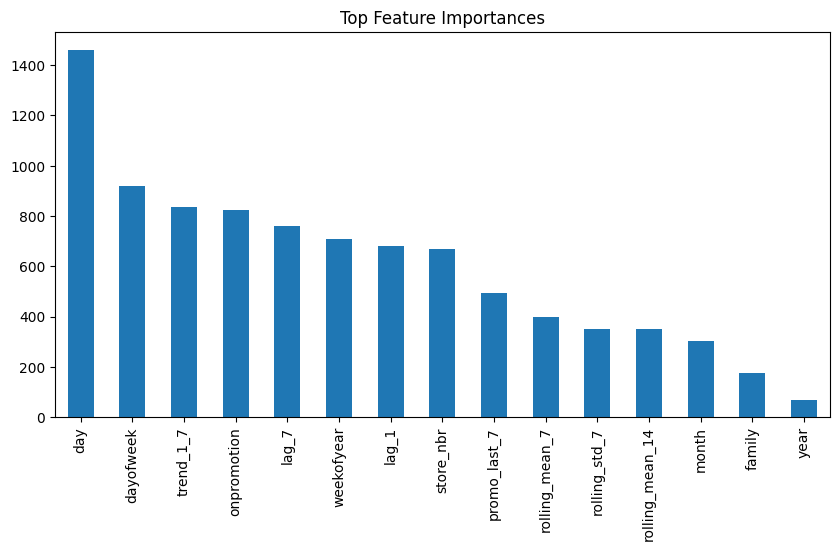

In [20]:
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.head(15).plot(kind="bar")
plt.title("Top Feature Importances")
plt.show()